# Ejercicio 1: Evaluación de solicitud de crédito bancario

**Curso:** Inteligencia Artificial I - IS484  
**Práctica:** Práctica Calificada 001  
**Estudiante:** Alexis Huamani Rivera

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P - Medida de desempeño** | Tomar decisiones de crédito coherentes con el nivel de riesgo, reduciendo la aprobación de solicitudes con alta probabilidad de incumplimiento y evitando rechazar innecesariamente solicitudes viables. |
| **E - Entorno** | Solicitudes de crédito bancario realizadas por clientes con diferentes ingresos, montos solicitados y antecedentes de morosidad. |
| **A - Actuadores** | Aprobar la solicitud, aprobarla con condiciones o rechazarla. |
| **S - Sensores / Percepciones** | Ingreso mensual del solicitante, monto solicitado e historial de morosidad. |

**Objetivo:** evaluar la capacidad económica y el riesgo del solicitante para tomar una decisión de crédito razonable y consistente.

### Justificación de las reglas

Para este ejercicio se utilizan reglas simplificadas que combinan la capacidad económica del solicitante con su historial de pago. Una relación monto/ingreso baja representa un menor nivel de exposición, mientras que una relación elevada aumenta el riesgo para el banco. El historial moroso se considera un factor adicional de riesgo, por lo que puede hacer más estricta la decisión.

#### Reglas de decisión

Se calcula primero:

`relacion = monto_solicitado / ingreso_mensual`

| Condición | Decisión |
|---|---|
| Sin historial moroso y relación ≤ 0.30 | **Aprobar** |
| Sin historial moroso y 0.30 < relación ≤ 0.50 | **Aprobar con condiciones** |
| Sin historial moroso y relación > 0.50 | **Rechazar** |
| Con historial moroso y relación ≤ 0.30 | **Aprobar con condiciones** |
| Con historial moroso y relación > 0.30 | **Rechazar** |

In [12]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Agente reactivo

    Percepciones:
    - ingreso_mensual: 
    - monto_solicitado: 
    - tiene_historial_moroso: 

    Acciones:
    - aprobar
    - aprobar con condiciones
    - rechazar
    """

    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.30:
            return (
                "aprobar con condiciones",
                f"relación monto/ingreso de {relacion:.2f} con historial moroso"
            )
        else:
            return (
                "rechazar",
                f"relación monto/ingreso de {relacion:.2f} con historial moroso"
            )

    else:
        if relacion <= 0.30:
            return (
                "aprobar",
                f"relación monto/ingreso de {relacion:.2f} sin historial moroso"
            )
        elif relacion <= 0.50:
            return (
                "aprobar con condiciones",
                f"relación monto/ingreso de {relacion:.2f} sin historial moroso"
            )
        else:
            return (
                "rechazar",
                f"relación monto/ingreso de {relacion:.2f} sin historial moroso"
            )

### Simulación y pruebas

Se evalúan diferentes perfiles de solicitantes para comprobar el comportamiento del agente.  
Las pruebas incluyen decisiones de aprobación, aprobación con condiciones y rechazo, además de casos límite donde la relación monto/ingreso es exactamente `0.30` y `0.50`.

In [13]:
casos_prueba = [
    # ingreso, monto, historial moroso
    (4000, 1000, False),  #  0.25 -> aprobar
    (4000, 1200, False),  #  0.30 -> caso límite
    (4000, 1600, False),  #  0.40 -> aprobar con condiciones
    (4000, 2000, False),  #  0.50 -> caso límite
    (4000, 2400, False),  #  0.60 -> rechazar
    (5000, 1000, True),   #  0.20 -> aprobar con condiciones
    (5000, 1500, True),   #  0.30 -> caso límite con historial
    (5000, 2000, True)    #  0.40 -> rechazar
]

for i, (ingreso, monto, historial) in enumerate(casos_prueba, start=1):
    accion, motivo = agente_credito(ingreso, monto, historial)
    relacion = monto / ingreso

    print(f"Caso {i}")
    print(f"Ingreso mensual: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Historial moroso: {'Sí' if historial else 'No'}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Caso 1
Ingreso mensual: S/ 4000
Monto solicitado: S/ 1000
Historial moroso: No
Relación monto/ingreso: 0.25
Decisión: aprobar
Motivo: relación monto/ingreso de 0.25 sin historial moroso
--------------------------------------------------
Caso 2
Ingreso mensual: S/ 4000
Monto solicitado: S/ 1200
Historial moroso: No
Relación monto/ingreso: 0.30
Decisión: aprobar
Motivo: relación monto/ingreso de 0.30 sin historial moroso
--------------------------------------------------
Caso 3
Ingreso mensual: S/ 4000
Monto solicitado: S/ 1600
Historial moroso: No
Relación monto/ingreso: 0.40
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso de 0.40 sin historial moroso
--------------------------------------------------
Caso 4
Ingreso mensual: S/ 4000
Monto solicitado: S/ 2000
Historial moroso: No
Relación monto/ingreso: 0.50
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso de 0.50 sin historial moroso
--------------------------------------------------
Caso 5
Ingreso mensu

### Visualización

Se generan 200 solicitudes de crédito aleatorias para observar cómo se distribuyen las decisiones del agente. Cada punto representa una solicitud; el eje horizontal muestra la relación entre el monto solicitado y el ingreso mensual, mientras que el eje vertical representa el ingreso mensual. El color indica la acción tomada por el agente.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para obtener resultados reproducibles
np.random.seed(42)

n = 200

# Generación de solicitudes aleatorias
ingresos = np.random.randint(1200, 10000, n)
montos = np.random.randint(300, 7000, n)
historiales = np.random.choice(
    [False, True],
    size=n,
    p=[0.75, 0.25]
)

resultados = []

for ingreso, monto, historial in zip(ingresos, montos, historiales):
    accion, motivo = agente_credito(
        ingreso,
        monto,
        historial
    )

    relacion = monto / ingreso

    resultados.append({
        "ingreso": ingreso,
        "monto": monto,
        "historial_moroso": historial,
        "relacion": relacion,
        "accion": accion
    })

In [15]:
print("Total de solicitudes simuladas:", len(resultados))

Total de solicitudes simuladas: 200


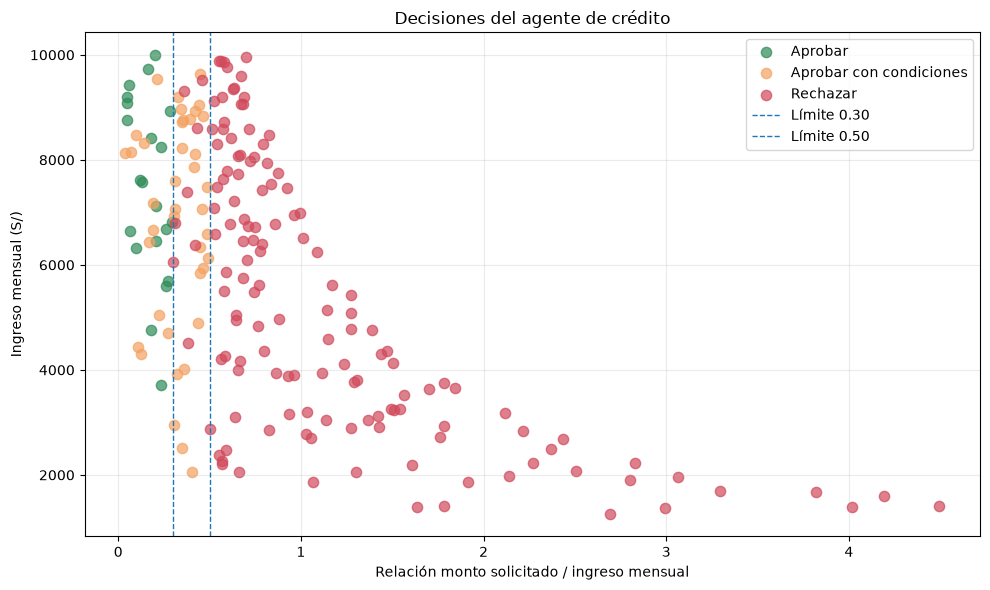

In [16]:
colores = {
    "aprobar": "#2E8B57",
    "aprobar con condiciones": "#F4A261",
    "rechazar": "#D1495B"
}

plt.figure(figsize=(10, 6))

for accion in colores:
    solicitudes = [
        solicitud
        for solicitud in resultados
        if solicitud["accion"] == accion
    ]

    x = [solicitud["relacion"] for solicitud in solicitudes]
    y = [solicitud["ingreso"] for solicitud in solicitudes]

    plt.scatter(
        x,
        y,
        label=accion.capitalize(),
        alpha=0.7,
        s=55,
        color=colores[accion]
    )

plt.axvline(
    x=0.30,
    linestyle="--",
    linewidth=1,
    label="Límite 0.30"
)

plt.axvline(
    x=0.50,
    linestyle="--",
    linewidth=1,
    label="Límite 0.50"
)

plt.title("Decisiones del agente de crédito")
plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

In [17]:
from collections import Counter

conteo_decisiones = Counter(
    solicitud["accion"]
    for solicitud in resultados
)

print("Resumen de decisiones:")
for accion, cantidad in conteo_decisiones.items():
    porcentaje = cantidad / n * 100
    print(
        f"{accion.capitalize()}: "
        f"{cantidad} solicitudes ({porcentaje:.1f}%)"
    )

Resumen de decisiones:
Rechazar: 139 solicitudes (69.5%)
Aprobar con condiciones: 40 solicitudes (20.0%)
Aprobar: 21 solicitudes (10.5%)
